## Baseline model

Denne notebooken trener en enkel CNN fra scratch som baseline for multi-label klassifisering av CheXpert-bildene.
Formålet er å etablere et sammenligningsgrunnlag før transfer learning med DenseNet-121.

In [44]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from google.colab import drive, userdata

In [45]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

print("TensorFlow version:", tf.__version__)
print("GPU available:", gpus)
print("Mixed precision policy:", mixed_precision.global_policy())

GPU memory growth enabled
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [46]:
drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/DAT255_CheXpert_Project")
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/DAT255_CheXpert_Project
PROCESSED_DIR exists: True


In [47]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

import kagglehub
DATASET_ROOT = Path(kagglehub.dataset_download("ashery/chexpert"))

print("DATASET_ROOT:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

Using Colab cache for faster access to the 'chexpert' dataset.
DATASET_ROOT: /kaggle/input/chexpert
Exists: True


In [48]:
LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_CSV = PROCESSED_DIR / "train_clean_competition_5_U-Ones.csv"
VALID_CSV = PROCESSED_DIR / "valid_clean_competition_5_U-Ones.csv"
PATH_COL = "Path"

NUM_LABELS = len(LABELS)

In [49]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

train_df.head()

Train shape: (191027, 22)
Valid shape: (202, 22)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,image_path,label_vector,file_exists
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,0.0,NaN,NaN,...,NaN,0.0,0.0,0.0,NaN,NaN,1.0,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 0.0, 0.0]",True
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,1.0,1.0,NaN,...,NaN,1.0,NaN,1.0,NaN,1.0,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[1.0, 1.0, 1.0, 1.0, 1.0]",True
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,0.0,1.0,NaN,...,NaN,0.0,NaN,0.0,NaN,1.0,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 1.0, 0.0, 0.0]",True
3,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,0.0,NaN,NaN,...,NaN,0.0,0.0,0.0,NaN,NaN,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 1.0, 0.0]",True
4,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 0.0, 0.0]",True


In [50]:
def adjust_path(path_str, dataset_root):
    path_str = str(path_str)
    prefix = "CheXpert-v1.0-small/"
    if path_str.startswith(prefix):
        path_str = path_str[len(prefix):]
    return str(dataset_root / path_str)

train_df["image_path"] = train_df[PATH_COL].apply(lambda p: adjust_path(p, DATASET_ROOT))
valid_df["image_path"] = valid_df[PATH_COL].apply(lambda p: adjust_path(p, DATASET_ROOT))

In [51]:
print("Columns:", train_df.columns.tolist())
print("\nTrain label sums:")
print(train_df[LABELS].sum())

print("\nValid label sums:")
print(valid_df[LABELS].sum())

print("\nMissing labels train:")
print(train_df[LABELS].isna().sum())

print("\nMissing labels valid:")
print(valid_df[LABELS].isna().sum())

print("\nFirst image exists:", Path(train_df["image_path"].iloc[0]).exists())
print(train_df[["image_path"] + LABELS].head())

Columns: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'image_path', 'label_vector', 'file_exists']

Train label sums:
Atelectasis         59583.0
Cardiomegaly        30092.0
Consolidation       37364.0
Edema               61493.0
Pleural Effusion    86477.0
dtype: float64

Valid label sums:
Atelectasis         75.0
Cardiomegaly        66.0
Consolidation       32.0
Edema               42.0
Pleural Effusion    64.0
dtype: float64

Missing labels train:
Atelectasis         0
Cardiomegaly        0
Consolidation       0
Edema               0
Pleural Effusion    0
dtype: int64

Missing labels valid:
Atelectasis         0
Cardiomegaly        0
Consolidation       0
Edema               0
Pleural Effusion    0
dtype: int64

First image exists: True
               

In [52]:
train_df = train_df[train_df["image_path"].apply(lambda p: Path(p).exists())].copy()
valid_df = valid_df[valid_df["image_path"].apply(lambda p: Path(p).exists())].copy()

print("After path filtering:")
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)

After path filtering:
Train: (191027, 22)
Valid: (202, 22)


## Data augmentation
Vi bruker lysgeometrisk augmentasjon for å forbedre generaliseringen. Horisontal flipping unngås fordi venstre/høyre-orientering i røntgenbilder av thorax kan ha klinisk betydning.

In [53]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="data_augmentation")

In [54]:
def load_image(path, labels):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    labels = tf.cast(labels, tf.float32)
    return image, labels

In [55]:
train_ds = tf.data.Dataset.from_tensor_slices((
    train_df["image_path"].values,
    train_df[LABELS].values.astype("float32")
))

valid_ds = tf.data.Dataset.from_tensor_slices((
    valid_df["image_path"].values,
    valid_df[LABELS].values.astype("float32")
))

train_ds = (
    train_ds
    .shuffle(buffer_size=len(train_df), seed=SEED)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

valid_ds = (
    valid_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [56]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 5)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>


In [57]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_labels=5):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_labels, activation="sigmoid", dtype="float32")(x)

    return keras.Model(inputs, outputs, name="baseline_cnn")

# Multi-label classification

Hvert bilde kan inneholde flere funn samtidig. Derfor bruker vi sigmoid output (en uavhengig sannsynlighet per label) og BinaryCrossentropy som loss function.


In [58]:
model = build_baseline_cnn(input_shape=(224, 224, 3), num_labels=len(LABELS))

metrics = [
    keras.metrics.BinaryAccuracy(name="binary_accuracy"),
    keras.metrics.AUC(name="auc_roc", curve="ROC", multi_label=True),
    keras.metrics.AUC(name="auc_pr", curve="PR", multi_label=True),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 423,397 (1.62 MB)

 Trainable params: 422,437 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [59]:
checkpoint_path = MODEL_DIR / "baseline_cnn_best.keras"
csv_log_path = RESULTS_DIR / "baseline_cnn_training_log.csv"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_auc_roc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc_roc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc_roc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger(str(csv_log_path))
]

In [60]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
5969/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - auc_pr: 0.3713 - auc_roc: 0.6190 - binary_accuracy: 0.7308 - loss: 0.5499 - precision: 0.5800 - recall: 0.2302
Epoch 1: val_auc_roc improved from None to 0.76371, saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/baseline_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/baseline_cnn_best.keras
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 184s 30ms/step - auc_pr: 0.3910 - auc_roc: 0.6402 - binary_accuracy: 0.7382 - loss: 0.5404 - precision: 0.6075 - recall: 0.2565 - val_auc_pr: 0.5240 - val_auc_roc: 0.7637 - val_binary_accuracy: 0.7307 - val_loss: 0.5474 - val_precision: 0.5507 - val_recall: 0.1362 - learning_rate: 0.0010
Epoch 2/15
5968/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - auc_pr: 0.4320 - auc_roc: 0.6817 - binary_accuracy: 0.7512 - loss: 0.5216 - precision: 0.6488 - recall: 0.2978
Epoch 2: val_auc_roc improved from 0.76371 to 0.79752, saving model to /content/drive

## Lagring og evaluering

In [61]:
final_model_path = MODEL_DIR / "baseline_cnn_final.keras"
model.save(final_model_path)

print("Best model saved to:", checkpoint_path)
print("Final model saved to:", final_model_path)

Best model saved to: /content/drive/MyDrive/DAT255_CheXpert_Project/models/baseline_cnn_best.keras
Final model saved to: /content/drive/MyDrive/DAT255_CheXpert_Project/models/baseline_cnn_final.keras


In [62]:
eval_results = model.evaluate(valid_ds, return_dict=True)
eval_results

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc_pr: 0.6841 - auc_roc: 0.8556 - binary_accuracy: 0.7802 - loss: 0.4430 - precision: 0.8065 - recall: 0.2688


{'auc_pr': 0.6840613484382629,
 'auc_roc': 0.8556245565414429,
 'binary_accuracy': 0.7801980376243591,
 'loss': 0.4430384933948517,
 'precision': 0.8064516186714172,
 'recall': 0.2688172161579132}

In [63]:
metrics_path = RESULTS_DIR / "baseline_cnn_eval_metrics.json"

with open(metrics_path, "w") as f:
    json.dump({k: float(v) for k, v in eval_results.items()}, f, indent=2)

print("Saved metrics to:", metrics_path)

Saved metrics to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/baseline_cnn_eval_metrics.json


In [64]:
history_df = pd.DataFrame(history.history)
history_df.head()

,auc_pr,auc_roc,binary_accuracy,loss,precision,recall,val_auc_pr,val_auc_roc,val_binary_accuracy,val_loss,val_precision,val_recall,learning_rate
0,0.391044,0.640188,0.738204,0.540395,0.607478,0.256475,0.524033,0.763712,0.730693,0.547417,0.550725,0.136201,0.001
1,0.443130,0.691924,0.753425,0.516818,0.654877,0.303634,0.604571,0.797517,0.719802,0.542662,0.485294,0.236559,0.001
2,0.469992,0.712502,0.759310,0.505369,0.668797,0.325015,0.624566,0.814371,0.758416,0.533728,0.888889,0.143369,0.001
3,0.484608,0.722983,0.763023,0.498817,0.676018,0.339807,0.645737,0.833926,0.752475,0.589901,0.837209,0.129032,0.001
4,0.493934,0.730471,0.765209,0.493676,0.679798,0.348883,0.613840,0.802556,0.766337,0.482098,0.726316,0.247312,0.001


In [65]:
history_path = RESULTS_DIR / "baseline_cnn_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved history to:", history_path)

Saved history to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/baseline_cnn_history.csv


## Per-label ROC-AUC


In [66]:
from sklearn.metrics import roc_auc_score

y_true = []
y_pred = []

for images, labels in valid_ds:
    preds = model.predict(images, verbose=0)
    y_true.append(labels.numpy())
    y_pred.append(preds)

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

per_label_auc = {}
for i, label in enumerate(LABELS):
    try:
        per_label_auc[label] = float(roc_auc_score(y_true[:, i], y_pred[:, i]))
    except ValueError:
        per_label_auc[label] = None

per_label_auc

{'Atelectasis': 0.8203674540682415,
 'Cardiomegaly': 0.7736185383244207,
 'Consolidation': 0.8654411764705883,
 'Edema': 0.9287202380952381,
 'Pleural Effusion': 0.8908514492753622}

## Plott loss, AUC og PR-AUC



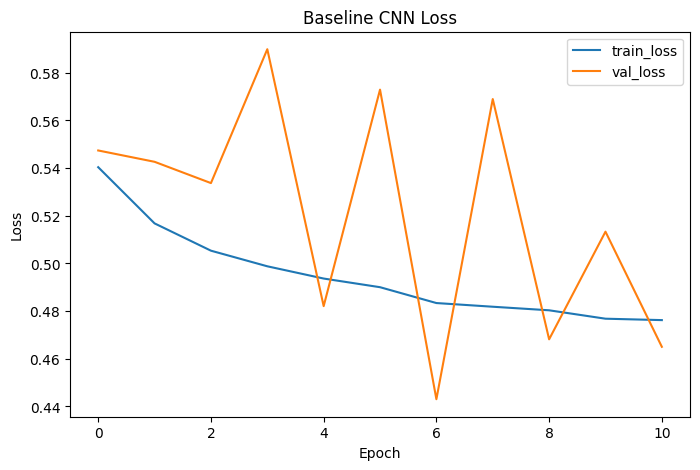

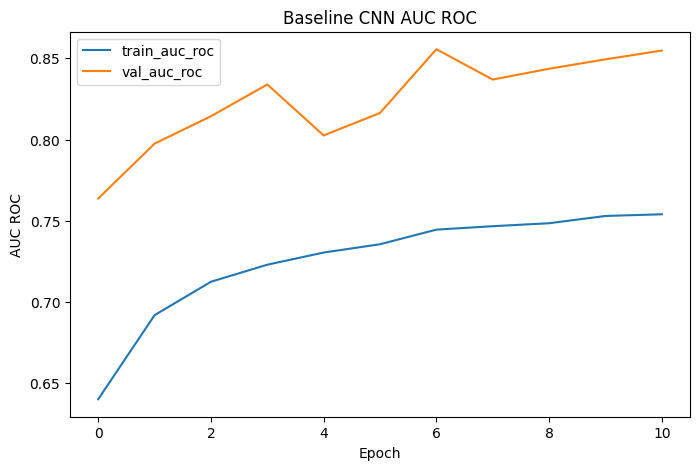

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()

plt.savefig(FIGURES_DIR / "baseline_cnn_loss.png", dpi=300, bbox_inches="tight")

plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_df["auc_roc"], label="train_auc_roc")
plt.plot(history_df["val_auc_roc"], label="val_auc_roc")

plt.xlabel("Epoch")
plt.ylabel("AUC ROC")
plt.title("Baseline CNN AUC ROC")
plt.legend()

plt.savefig(FIGURES_DIR / "baseline_cnn_auc.png", dpi=300, bbox_inches="tight")

plt.show()

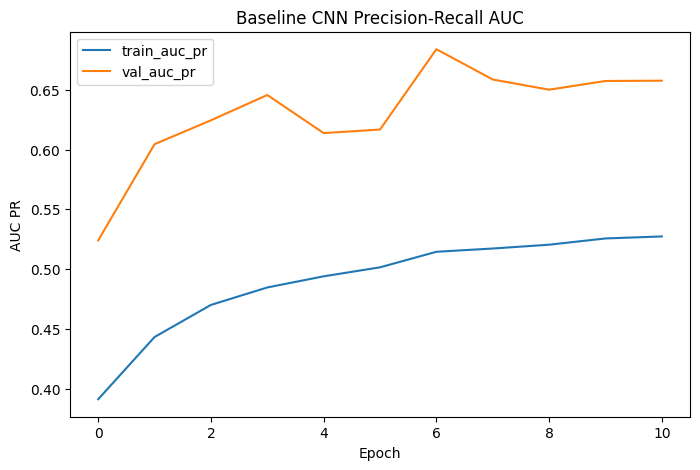

In [68]:
plt.figure(figsize=(8,5))
plt.plot(history_df["auc_pr"], label="train_auc_pr")
plt.plot(history_df["val_auc_pr"], label="val_auc_pr")

plt.xlabel("Epoch")
plt.ylabel("AUC PR")
plt.title("Baseline CNN Precision-Recall AUC")
plt.legend()

plt.savefig(FIGURES_DIR / "baseline_cnn_auc_pr.png", dpi=300, bbox_inches="tight")

plt.show()

## Enkel prediksjonssjekk

In [69]:
y_true = valid_df[LABELS].values.astype("float32")
y_pred = model.predict(valid_ds)

pred_df = valid_df[["image_path"] + LABELS].copy()
for i, label in enumerate(LABELS):
    pred_df[f"{label}_pred"] = y_pred[:, i]

pred_path = RESULTS_DIR / "baseline_cnn_validation_predictions.csv"
pred_df.to_csv(pred_path, index=False)
print("Saved predictions to:", pred_path)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Saved predictions to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/baseline_cnn_validation_predictions.csv
y_true shape: (202, 5)
y_pred shape: (202, 5)


### Per-label AUROC

In [70]:
from sklearn.metrics import roc_auc_score

per_label_auc = {}

for i, label in enumerate(LABELS):
    try:
        auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        per_label_auc[label] = float(auc)
    except ValueError:
        per_label_auc[label] = None

per_label_auc

{'Atelectasis': 0.8203674540682415,
 'Cardiomegaly': 0.7736185383244207,
 'Consolidation': 0.8654411764705883,
 'Edema': 0.9287202380952381,
 'Pleural Effusion': 0.8908514492753622}

## Lagre per-label resultater

In [71]:
per_label_auc_path = RESULTS_DIR / "baseline_cnn_per_label_auc.json"

with open(per_label_auc_path, "w") as f:
    json.dump(per_label_auc, f, indent=2)

print("Saved per-label AUC to:", per_label_auc_path)

Saved per-label AUC to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/baseline_cnn_per_label_auc.json


## Oppsummering

Denne notebooken trener en baseline-CNN fra scratch for multi-label klassifisering av de fem konkurranseklassene i CheXpert.
Modellen brukes som referansemodell før transfer learning med DenseNet-121 i neste notebook.

Lagrer:
- beste modell
- final modell
- treningslogg
- history
- evalueringsmetrikker
- per-label AUROC